In [10]:
# Auto-reload modules during development
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

# Import the framework
from nowkit.nowcasting_framework import (
    NowcastConfig,
    DataManager,
    ModelManager,
    EvaluationManager,
    VisualizationManager,
    InferencePipeline
)

# Import model
from sklearn.linear_model import LinearRegression

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Configuration

In [11]:
# Configure OLS experiment
# Using 3 lags (simpler model)
config = NowcastConfig(
    target_variable="gdpc1",
    test_start_date="2005-03-01",
    test_end_date="2010-03-01",
    n_lags=3,  # Fewer lags than other models
    n_ensemble_models=1,  # Deterministic model, no ensemble needed
    quarterly_only=True
)

print("OLS Regression Configuration:")
print("=" * 60)
for key, value in config.to_dict().items():
    print(f"{key:20s}: {value}")
print("=" * 60)

OLS Regression Configuration:
target              : gdpc1
test_period         : 2005-03-01 to 2010-03-01
lags                : [-2, -1, 0, 1, 2]
n_lags              : 3
n_ensemble          : 1


## 2. Data Loading

In [12]:
# Initialize and load data
data_manager = DataManager(config)
data_manager.load_data().prepare_test_data()

REAL_LAG = 1

# Apply realistic lags (In-Memory Patch)
# We force a 1-month lag on key indicators that were set to 0 (e.g. Employment, Ind. Production)
# This prevents the model from "peeking" at data that wouldn't be released yet on the 1st of the month.
print("\nApplying realistic publication lags (patching metadata in memory):")
realistic_lag_vars = ['payems', 'indpro', 'unrate', 'permit', 'tcu', 'ir', 'cpilfesl', 'iq']
for var in realistic_lag_vars:
    mask = data_manager.metadata.series == var
    if mask.any():
        #data_manager.metadata.loc[mask, 'months_lag'] = REAL_LAG
        #print(f"  -> Set {var} lag to {REAL_LAG} month")
        ...
# Display data summary
data_manager.summary()

✓ Loaded data: (913, 25)
✓ Loaded metadata: (24, 8)
✓ Test data prepared: 21 periods

Applying realistic publication lags (patching metadata in memory):


,Metric,Value
0,Total Observations,913
1,Test Periods,21
2,Variables,24
3,Target Variable,gdpc1
4,Missing in Target (%),66.9%


In [13]:
data_manager.metadata

,series,name,freq,block_g,block_s,block_r,block_l,months_lag
0,payems,Payroll Employment,m,1,0,0,1,0
1,gdpc1,Real Gross Domestic Product,q,1,0,1,0,4
2,cpiaucsl,Consumer Price Index,m,1,0,0,0,1
3,dgorder,Durable Goods Orders,m,1,0,1,0,1
4,hsn1f,New Home Sales,m,1,0,1,0,1
5,rsafs,Retail Sales,m,1,0,1,0,1
6,unrate,Unemployment Rate,m,1,0,0,1,0
7,houst,Housing Starts,m,1,0,1,0,1
8,indpro,Industrial Production,m,1,0,1,0,0
9,dspic96,Personal Income,m,1,0,1,0,1


## 3. Model Training and Backtesting

In [14]:
# Configure OLS parameters (no hyperparameters)
ols_params = {}

# Create model manager and run backtest
ols_model = ModelManager(LinearRegression, ols_params, config)
ols_model.run_backtest(data_manager)


Running backtest with 1 ensemble model(s)...
  Processing 5/21 dates...
  Processing 5/21 dates...
  Processing 10/21 dates...
  Processing 10/21 dates...
  Processing 15/21 dates...
  Processing 15/21 dates...
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed


## 4. Evaluation

In [15]:
# Evaluate model performance
evaluator = EvaluationManager()
evaluator.add_model_results(
    'OLS (3 lags)',
    ols_model.get_predictions(),
    data_manager.actuals,
    config.lags
)

# Display performance metrics
print("\nPERFORMANCE BY VINTAGE:")
print("-" * 60)
display(evaluator.get_performance_table().round(6))

print("\n" + evaluator.summary_report())


PERFORMANCE BY VINTAGE:
------------------------------------------------------------


Model,Vintage,OLS (3 lags)
0,-2,0.009149
1,-1,0.009906
2,0,0.006730
3,1,0.009168
4,2,0.005978



MODEL EVALUATION SUMMARY

Model: OLS (3 lags)
  Average RMSE across vintages: 0.008186
  Best vintage: lag=2 (RMSE=0.005978)



## 5. Visualization

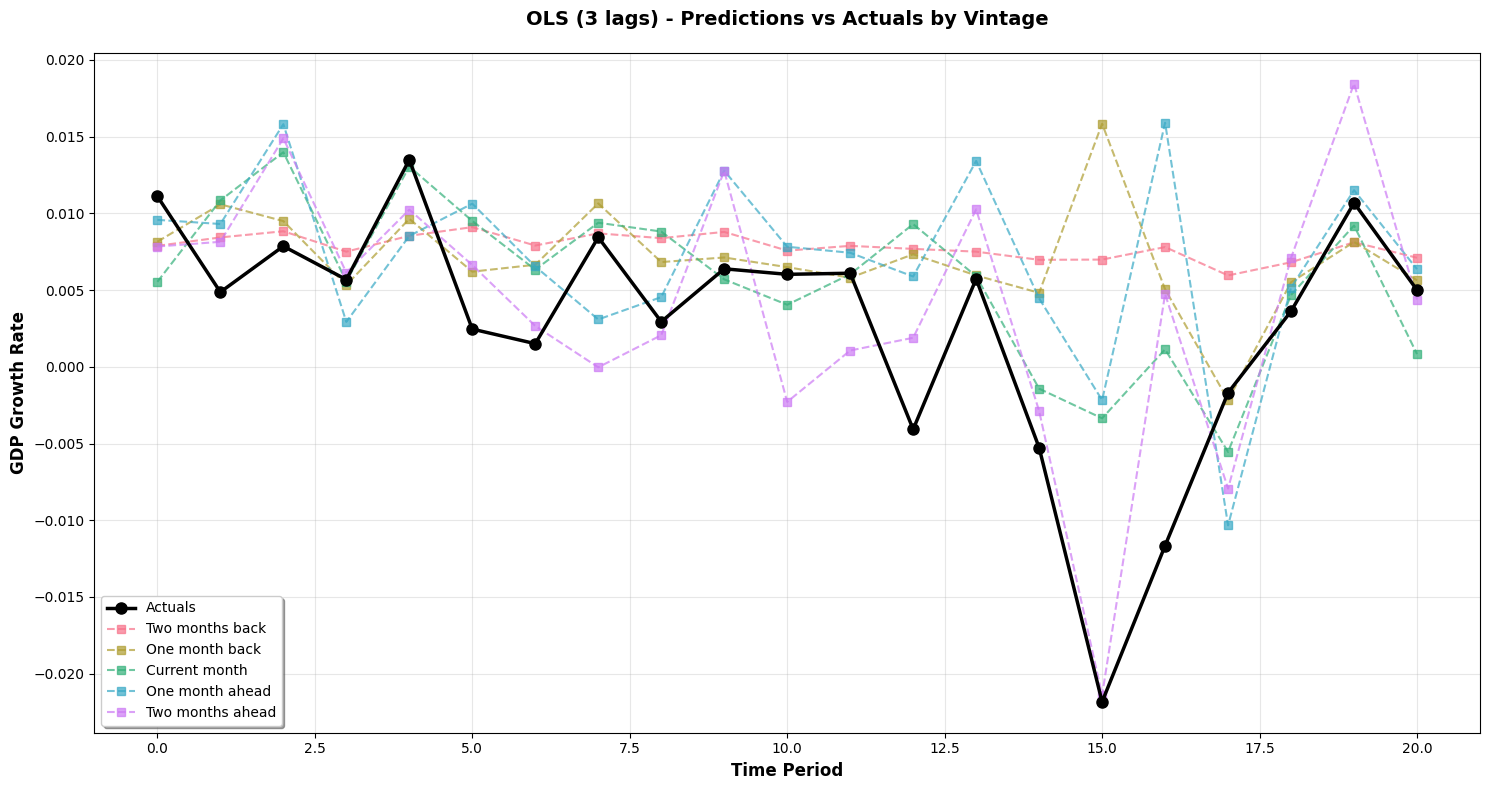

In [16]:
# Create visualization manager
viz = VisualizationManager(evaluator)

# Plot predictions vs actuals
fig1 = viz.plot_predictions_vs_actuals('OLS (3 lags)')
plt.show()

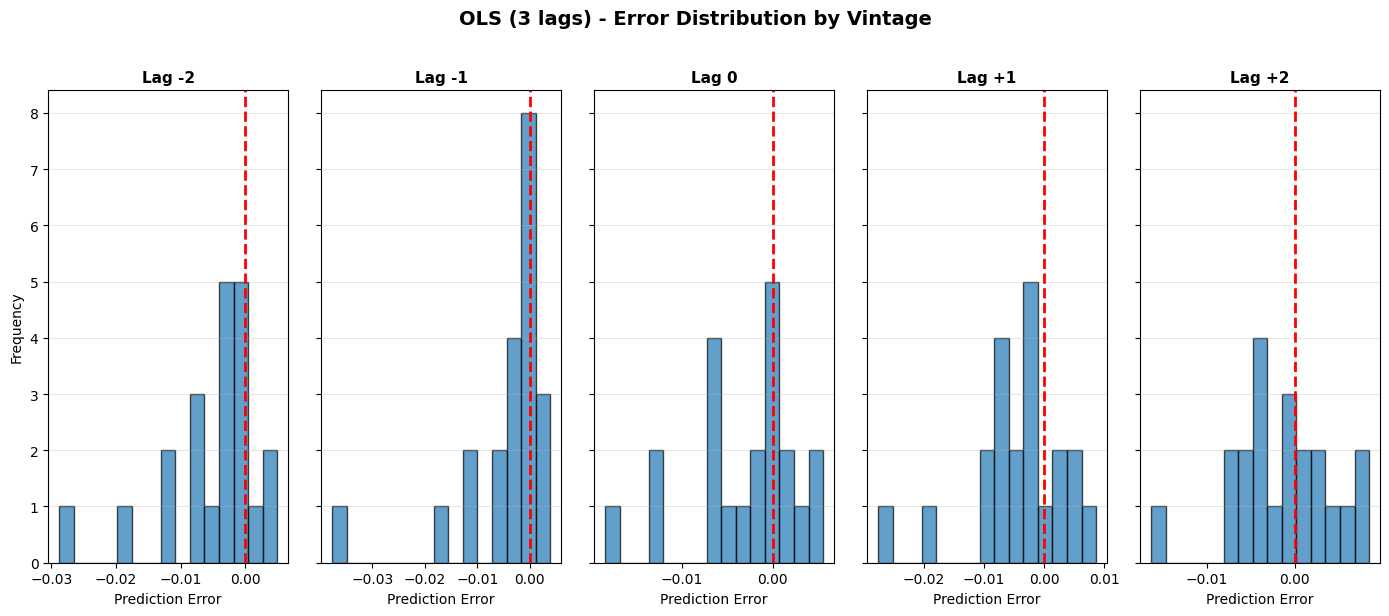

In [17]:
# Plot error distribution
fig2 = viz.plot_error_distribution('OLS (3 lags)')
plt.show()

## 6. Production Inference

In [18]:
# Create inference pipeline
inference = InferencePipeline(ols_model, data_manager, config)

# Predict future quarter
prediction = inference.predict_new_date("2010-06-01")

print("\nFUTURE PREDICTION:")
print("=" * 60)
for key, value in prediction.items():
    print(f"{key:20s}: {value}")


FUTURE PREDICTION:
target_date         : 2010-06-01
prediction          : 0.00810431713556708
target_variable     : gdpc1
n_models            : 1
model_class         : LinearRegression


## Summary

This notebook implements ordinary least squares (OLS) regression for GDP nowcasting. OLS serves as a useful baseline model without any regularization. We use 3 lags instead of 4, keeping the feature space simpler compared to other models.

Since OLS has no hyperparameters to tune and is deterministic, it provides a straightforward benchmark for evaluating more complex approaches. The framework makes it easy to compare OLS performance against regularized and ensemble methods.